In [2]:
import networkx as nx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from bp_error.perc_func import declare_vector, perc_log_meesage_pass, update_v_and_messages
import math

In [6]:
N = 10 #no. of nodes
p = 0.4 #ocu
G = nx.erdos_renyi_graph(N, p)
G_di = nx.DiGraph(G)
A = nx.to_numpy_array(G)
pos = nx.spring_layout(G)
labels = {node: str(node) for node in G.nodes()}

{0: Text(-0.5418850983904095, 0.6732126620149735, '0'),
 1: Text(0.15576565557615507, 0.3998992491751974, '1'),
 2: Text(0.34634214275361475, 0.02069286734871119, '2'),
 3: Text(0.3402578884913112, -0.48094088414957986, '3'),
 4: Text(0.04832873430971524, -0.26681945448699423, '4'),
 5: Text(-0.15530422105515357, 1.0, '5'),
 6: Text(-0.21518329187567, 0.018204012380906746, '6'),
 7: Text(-0.5783723885465453, -0.5828950924313738, '7'),
 8: Text(0.7048313941129476, 0.039098263392326235, '8'),
 9: Text(-0.10478081537596477, -0.820451623244166, '9')}

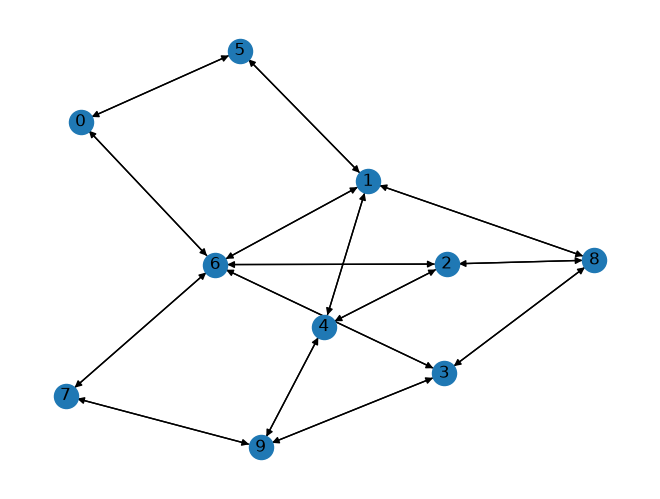

In [18]:
nx.draw(G_di, pos)
nx.draw_networkx_labels(G, pos, labels)

In [ ]:
edge_list = list(G_di.edges())
edge_loc = {}
i = 0
for edge in edge_list:
    edge_loc[edge] = i
    i += 1
messages = {}
B = {}
V = []
print(edge_list)
neighbor_edges = [list(G_di.edges(i, data=True)) for i in edge_list]

{(0, 5): 0, (0, 6): 1, (1, 4): 2, (1, 5): 3, (1, 6): 4, (1, 8): 5, (2, 4): 6, (2, 6): 7, (2, 8): 8, (3, 6): 9, (3, 8): 10, (3, 9): 11, (4, 1): 12, (4, 2): 13, (4, 9): 14, (5, 0): 15, (5, 1): 16, (6, 0): 17, (6, 1): 18, (6, 2): 19, (6, 3): 20, (6, 7): 21, (7, 6): 22, (7, 9): 23, (8, 1): 24, (8, 2): 25, (8, 3): 26, (9, 3): 27, (9, 4): 28, (9, 7): 29}


In [38]:
B = [[0 for i in range(G_di.number_of_edges())] for j in range(G_di.number_of_edges())]

row = 0
for neighbor_list in neighbor_edges:
    edge = edge_list[row]
    col = 0
    i, j = edge[0], edge[1]
    for neighbor in neighbor_list:
        if (neighbor[0] == i and neighbor[1] != j) or (neighbor[0] == j and neighbor[1] != i):
            temp_tup = (neighbor[0], neighbor[1])
            B[row][edge_loc[temp_tup]] = 1
    row += 1
for row in B:
    print(row)

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]

In [49]:
B = jnp.array(B)
V = jnp.array([math.log(1-p + p*0.5) for i in range(G_di.number_of_edges())])
messages = jnp.array(jnp.matmul(B, V))
i = 0
for message in messages:
    print(edge_list[i], math.exp(message))
    i += 1

(0, 5) 0.6400000045322861
(0, 6) 0.3276799960357013
(1, 4) 0.3276799960357013
(1, 5) 0.40960000580132633
(1, 6) 0.20971518644798878
(1, 8) 0.3276799960357013
(2, 4) 0.40960000580132633
(2, 6) 0.2621439899442734
(2, 8) 0.40960000580132633
(3, 6) 0.2621439899442734
(3, 8) 0.40960000580132633
(3, 9) 0.40960000580132633
(4, 1) 0.3276799960357013
(4, 2) 0.40960000580132633
(4, 9) 0.40960000580132633
(5, 0) 0.6400000045322861
(5, 1) 0.40960000580132633
(6, 0) 0.3276799960357013
(6, 1) 0.20971518644798878
(6, 2) 0.2621439899442734
(6, 3) 0.2621439899442734
(6, 7) 0.3276799960357013
(7, 6) 0.3276799960357013
(7, 9) 0.5120000206975328
(8, 1) 0.3276799960357013
(8, 2) 0.40960000580132633
(8, 3) 0.40960000580132633
(9, 3) 0.40960000580132633
(9, 4) 0.40960000580132633
(9, 7) 0.5120000206975328
